In [2]:
import yfinance as yf

In [3]:
import pandas as pd


In [4]:
import numpy as np

In [5]:
ticker_symbol = "MSFT"

In [6]:
start_date = '2025-01-01'

In [7]:
end_date = '2026-02-02'

In [8]:
stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


## Calculating Daily Returns

In [9]:
stock_data['returns'] = stock_data['Close'].pct_change()

In [15]:
print(stock_data)

Price            Close        High         Low        Open     Volume  \
Ticker            MSFT        MSFT        MSFT        MSFT       MSFT   
Date                                                                    
2025-01-02  415.514832  422.950005  411.812165  422.413951   16896500   
2025-01-03  420.249939  420.924952  416.467841  417.996542   16662900   
2025-01-06  424.716980  431.139603  422.364340  424.865876   20573600   
2025-01-07  419.277100  427.496466  417.718589  425.858555   18139100   
2025-01-08  421.451019  423.843375  418.453145  420.359068   15054600   
...                ...         ...         ...         ...        ...   
2026-01-26  470.279999  474.250000  462.000000  465.309998   29291200   
2026-01-27  480.579987  482.869995  473.160004  473.700012   29213900   
2026-01-28  481.630005  483.739990  478.000000  483.209991   36875400   
2026-01-29  433.500000  442.500000  421.019989  439.989990  128855300   
2026-01-30  430.290009  439.600006  426.450012  439

In [11]:
window_size = 5

In [14]:
stock_data['volatility'] = stock_data['returns'].rolling(window=window_size).std() * np.sqrt(252) # Annualized volatility

In [16]:
print(stock_data)

Price            Close        High         Low        Open     Volume  \
Ticker            MSFT        MSFT        MSFT        MSFT       MSFT   
Date                                                                    
2025-01-02  415.514832  422.950005  411.812165  422.413951   16896500   
2025-01-03  420.249939  420.924952  416.467841  417.996542   16662900   
2025-01-06  424.716980  431.139603  422.364340  424.865876   20573600   
2025-01-07  419.277100  427.496466  417.718589  425.858555   18139100   
2025-01-08  421.451019  423.843375  418.453145  420.359068   15054600   
...                ...         ...         ...         ...        ...   
2026-01-26  470.279999  474.250000  462.000000  465.309998   29291200   
2026-01-27  480.579987  482.869995  473.160004  473.700012   29213900   
2026-01-28  481.630005  483.739990  478.000000  483.209991   36875400   
2026-01-29  433.500000  442.500000  421.019989  439.989990  128855300   
2026-01-30  430.290009  439.600006  426.450012  439

In [20]:
# Loop starting from the second item (index 1)
for idx, value in stock_data['returns'].iloc[1:].items():
    # print(f"Index: {idx}, Return: {value}")
    assert abs(value) >= 0

In [27]:
assert np.isnan(stock_data['returns'].iloc[0]) , "expected first return to be NaN"

# Plot Stock Volatility 

In [32]:
import matplotlib.pyplot as plt

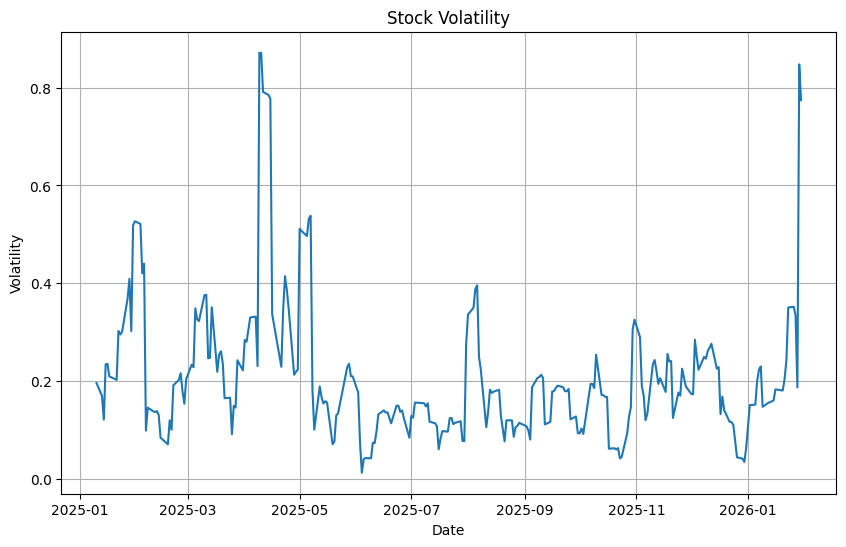

In [33]:
# Line chart for daily returns
plt.figure(figsize=(10, 6))
plt.plot(stock_data.index, stock_data['volatility'])
plt.title('Stock Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()

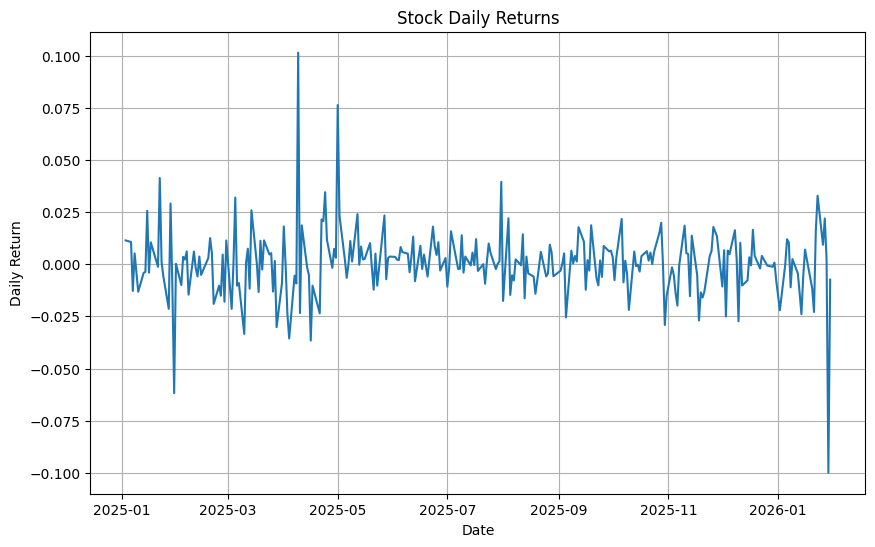

In [38]:
# Line chart for daily returns
plt.figure(figsize=(10, 6))
plt.plot(stock_data.index, stock_data['returns'])
plt.title('Stock Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()

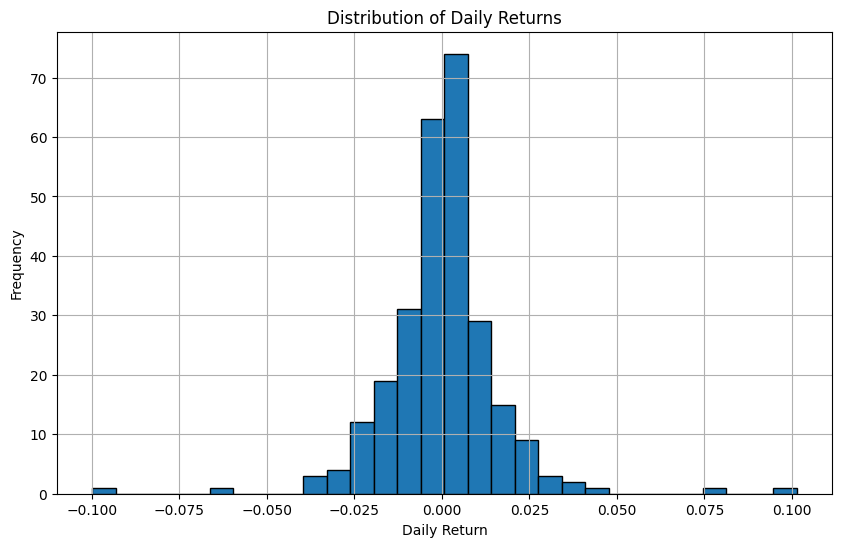

In [37]:
# Histogram of returns
plt.figure(figsize=(10, 6))
plt.hist(stock_data['returns'], bins=30, edgecolor='black')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()